# Joy's Smiski Shop vs. Leshui's Live Laugh Labubu

**ECON 306 | Project #1**  
**Research question:** When two toy shops choose prices simultaneously, can the expectation that a rival will discount lead both shops to discount and earn less than if both had kept prices high?

This notebook builds and solves a two-player, one-shot pricing game between collectible shops. It uses a transparent illustrative demand model and computes the payoff matrix and the game's pure- and mixed-strategy Nash equilibria. Prices and costs are dollars per collectible; the calibration is a thought experiment, not an estimate from real shops.

## 1. Introduction: why this question matters

JSS (Joy's Smiski Shop) and 4L (Leshui's Live Laugh Labubu) compete for customers who collect character figures. A price cut can attract customers from a rival while reducing the seller's margin. The strategic issue is that each owner chooses while anticipating the other's incentives. A one-time choice made without seeing the rival's decision is a **simultaneous-move game**, even if the posted prices later become visible.

The question is not whether discounting is always bad. It is whether, under clear and plausible conditions, a shop's expectation that its rival will discount can make discounting privately optimal, even though both shops would earn more if both kept prices high. This is useful for understanding retail price competition and the difference between individual incentives and joint outcomes.

## 2. Model setup

**Players.** Joy's Smiski Shop (JSS) and Leshui's Live Laugh Labubu (4L) are symmetric, profit-maximizing collectible retailers. For this model, their figures are treated as close substitutes, even though the shops' brands differ.  
**Actions.** Each simultaneously selects one posted price per figure: **Discount** ($20.00) or **Regular** ($30.00).  
**Information and timing.** Both know the demand rule, costs, and action set; neither observes the other's current price before choosing. Prices and sales are realized after both choose.  
**Payoffs.** Each shop's payoff is operating profit from this period, with no fixed costs.

| Symbol | Meaning | Baseline |
|:--|:--|--:|
| $N$ | Total customers shopping for a collectible in this market | 100 |
| $c$ | Marginal acquisition cost per figure | $10.00 |
| $p_D, p_R$ | Discount and regular prices per figure | $20.00, $30.00 |
| $\beta$ | Customers shifting toward a shop per $1 rival-price advantage | 3 |
| $x=\beta(p_R-p_D)$ | Customers switching when prices differ by one action step | 30 |

These parameters are deliberately simple and illustrative; different values for customer switching or margins could change the shops' best responses.

### Demand, payoffs, and equilibrium

If JSS charges $p_{JSS}$ and 4L charges $p_{4L}$, the number of customers each shop serves is

$$Q_{JSS}=\frac{N}{2}+\beta(p_{4L}-p_{JSS}), \qquad Q_{4L}=\frac{N}{2}+\beta(p_{JSS}-p_{4L}), \qquad Q_{JSS}+Q_{4L}=N.$$

A \$10.00 price advantage (Discount against Regular) therefore shifts $x=30$ customers: if JSS discounts while 4L charges Regular, JSS serves 80 customers and 4L serves 20, and the reverse if 4L discounts. When JSS and 4L charge the same price, each serves 50. This reduced-form rule keeps total market demand fixed and represents customers switching between JSS and 4L; it does not model whether someone opts out of buying a collectible.

Each shop's payoff is its profit: $\pi_{JSS}=(p_{JSS}-c)\,Q_{JSS}$ and $\pi_{4L}=(p_{4L}-c)\,Q_{4L}$. With a \$10 margin at Discount and a \$20 margin at Regular, the four possible outcomes are:

| JSS's price | 4L's price | JSS customers | 4L customers | JSS profit | 4L profit |
|:--|:--|--:|--:|--:|--:|
| Discount | Discount | 50 | 50 | \$500 | \$500 |
| Discount | Regular | 80 | 20 | \$800 | \$400 |
| Regular | Discount | 20 | 80 | \$400 | \$800 |
| Regular | Regular | 50 | 50 | \$1,000 | \$1,000 |

We solve for two kinds of Nash equilibrium:

- A **pure-strategy Nash equilibrium** is a pair of prices where neither JSS nor 4L can raise its profit by changing its own price alone.
- A **mixed-strategy Nash equilibrium** is a pair of probabilities of choosing Regular, one for JSS and one for 4L, where each shop's mix is a best response to the other's. When a shop puts positive probability on both prices, this requires it to be indifferent between them; in this game, that pins down the probability of Regular for each shop. The pure-strategy equilibria are the special cases where each probability is 0 or 1. We write $q$ for a shop's probability of choosing Regular.

Shop owners do not literally flip a coin to set prices. One way to read $q$ is as a **belief**: how likely JSS thinks it is that 4L charges Regular, and vice versa; in equilibrium, those beliefs are correct. Another is as a **frequency**: each shop charges Regular in a fraction $q$ of weeks, so its rival cannot predict any particular week's price.

JSS and 4L choose at the same time; the Nash test asks what each shop would earn by deviating alone, and does not mean the owners move in sequence.

In [1]:
from itertools import product

import pandas as pd

N = 100
marginal_cost = 10.00
prices = {"Discount": 20.00, "Regular": 30.00}
beta = 3.0
shop_names = ("JSS", "4L")
actions = tuple(prices)
switch_count = beta * (prices["Regular"] - prices["Discount"])

def payoff_at_switch_count(action_a, action_b, x):
    """Return (profit A, profit B, quantity A, quantity B) for a switch count x."""
    price_a, price_b = prices[action_a], prices[action_b]
    quantity_a = N / 2 + x * (price_b - price_a) / (prices["Regular"] - prices["Discount"])
    quantity_b = N - quantity_a
    if not (0 <= quantity_a <= N):
        raise ValueError("The switching parameter implies demand outside [0, N].")
    profit_a = (price_a - marginal_cost) * quantity_a
    profit_b = (price_b - marginal_cost) * quantity_b
    return profit_a, profit_b, quantity_a, quantity_b

assert switch_count == 30
assert payoff_at_switch_count("Discount", "Regular", switch_count)[2:] == (80.0, 20.0)
print(f"One action-step price advantage shifts {switch_count:.0f} customers.")

One action-step price advantage shifts 30 customers.


In [2]:
from IPython.display import HTML

profiles = list(product(actions, repeat=2))
payoffs = {profile: payoff_at_switch_count(*profile, switch_count)[:2] for profile in profiles}

P1_COLOR, P2_COLOR = "#d62728", "#1f5bd8"

def game_table(payoffs, players=shop_names, actions=actions):
    """Render a 2-player normal-form game: P1 (rows) in red, P2 (columns) in blue."""
    plain = "border:none; background:transparent; padding:2px 10px;"
    boxed = "border:1.5px solid currentColor; background:transparent; padding:4px 14px; text-align:center;"
    label = "font-size:1.15em; padding:2px 10px; border:none; background:transparent;"

    rows = [
        f"<tr><td style='{plain}'></td><td style='{plain}'></td>"
        f"<td colspan='{len(actions)}' style='{label} color:{P2_COLOR}; text-align:center;'>{players[1]}</td></tr>",
        f"<tr><td style='{plain}'></td><td style='{plain}'></td>"
        + "".join(f"<td style='{plain} text-align:center;'>{b}</td>" for b in actions) + "</tr>",
    ]
    for i, a in enumerate(actions):
        p1_label = (f"<td rowspan='{len(actions)}' style='{label} color:{P1_COLOR}; vertical-align:middle;'>{players[0]}</td>"
                    if i == 0 else "")
        cells = "".join(
            f"<td style='{boxed}'>(<span style='color:{P1_COLOR}'>{payoffs[(a, b)][0]:,.0f}</span>,"
            f"<span style='color:{P2_COLOR}'>{payoffs[(a, b)][1]:,.0f}</span>)</td>"
            for b in actions
        )
        rows.append(f"<tr>{p1_label}<td style='{plain} text-align:right;'>{a}</td>{cells}</tr>")
    return HTML("<table style='border-collapse:collapse; margin:8px 0; font-family:serif; font-size:1.05em;'>"
                + "".join(rows) + "</table>")

print(f"Payoffs are ({shop_names[0]} profit, {shop_names[1]} profit), in dollars per period.")
display(game_table(payoffs))

Payoffs are (JSS profit, 4L profit), in dollars per period.


In [3]:
def best_responses(player, rival_action, x):
    """Find every profit-maximizing action for player 0 (JSS) or 1 (4L)."""
    own_payoffs = {}
    for action in actions:
        profile = (action, rival_action) if player == 0 else (rival_action, action)
        own_payoffs[action] = payoff_at_switch_count(*profile, x)[player]
    best_value = max(own_payoffs.values())
    return {action for action, value in own_payoffs.items() if abs(value - best_value) < 1e-9}

def pure_nash_equilibria(x):
    """Enumerate profiles in which both actions are mutual best responses."""
    equilibria = []
    for action_a, action_b in product(actions, repeat=2):
        if action_a in best_responses(0, action_b, x) and action_b in best_responses(1, action_a, x):
            equilibria.append((action_a, action_b))
    return equilibria

response_rows = []
for rival_action in actions:
    response_rows.append({
        "Rival's action": rival_action,
        "JSS's best response(s)": ", ".join(sorted(best_responses(0, rival_action, switch_count))),
        "Profit if Discount": payoff_at_switch_count("Discount", rival_action, switch_count)[0],
        "Profit if Regular": payoff_at_switch_count("Regular", rival_action, switch_count)[0],
    })
display(pd.DataFrame(response_rows).set_index("Rival's action").round(2))

equilibria = pure_nash_equilibria(switch_count)
assert equilibria == [("Discount", "Discount"), ("Regular", "Regular")]
print("Pure-strategy Nash equilibria (JSS action, 4L action):")
for profile in equilibria:
    print("  (" + ", ".join(profile) + ")")

,JSS's best response(s),Profit if Discount,Profit if Regular
Rival's action,,,
Discount,Discount,500.0,400.0
Regular,Regular,800.0,1000.0


Pure-strategy Nash equilibria (JSS action, 4L action):
  (Discount, Discount)
  (Regular, Regular)


## 3. Analysis: solve and interpret the game

At the baseline, neither action is dominant; each shop's best response depends on its rival's price. The computed payoff matrix is:

$$
\begin{array}{r|c|c|}
\textcolor{red}{\text{JSS}} \,\backslash\, \textcolor{blue}{\text{4L}} & \textcolor{blue}{\text{Discount}} & \textcolor{blue}{\text{Regular}} \\ \hline
\textcolor{red}{\text{Discount}} & (\textcolor{red}{500},\ \textcolor{blue}{500}) & (\textcolor{red}{800},\ \textcolor{blue}{400}) \\ \hline
\textcolor{red}{\text{Regular}} & (\textcolor{red}{400},\ \textcolor{blue}{800}) & (\textcolor{red}{1000},\ \textcolor{blue}{1000}) \\ \hline
\end{array}
$$

The matrix entries are (JSS profit, 4L profit), in dollars per period. If both choose Discount, each earns $500. If both choose Regular, each earns $1,000. When prices differ, the lower-priced shop serves 80 customers and earns $800; the higher-priced shop serves 20 and earns $400.

There are **two pure-strategy Nash equilibria**: **(Discount, Discount)** and **(Regular, Regular)**. Against a Discount rival, Discount earns $500 versus $400 from Regular, so Discount is the best response. Against a Regular rival, Regular earns $1,000 versus $800 from Discount, so Regular is the best response. This is a **coordination game**: each shop prefers matching the rival's price, and both earn more when both choose Regular. Neither symmetric outcome is uniquely selected by the one-shot model.

Which equilibrium is better depends on whose outcome is being considered. Both shops earn more at (Regular, Regular) ($1,000 each) than at (Discount, Discount) ($500 each), while customers pay less for the collectible at the discount price. Since total customers are fixed here, the model alone cannot measure changes in consumer surplus, product quality, or total welfare.

### Mixed-strategy equilibrium

Because each shop wants to match its rival, there is also a **mixed-strategy Nash equilibrium**, in which each shop randomizes so that its rival is indifferent between Discount and Regular. Suppose 4L chooses Regular with probability $q$ and Discount with probability $1-q$. JSS's expected profits are

$$E[\pi_{JSS}(\text{Discount})] = 500(1-q) + 800q, \qquad E[\pi_{JSS}(\text{Regular})] = 400(1-q) + 1000q.$$

Setting these equal gives $500 + 300q = 400 + 600q$, so $q = 1/3$. The game is symmetric, so the same calculation applies to 4L. In the mixed equilibrium, **each shop chooses Regular with probability 1/3 and Discount with probability 2/3**, and each earns an expected profit of $500 + 300(1/3) = 600$ dollars.

That expected profit is above the (Discount, Discount) payoff of 500 but well below the (Regular, Regular) payoff of 1,000, so even when the shops randomize, both earn less than if they coordinated on Regular.

In [4]:
from fractions import Fraction

def own_profit(own_action, rival_action):
    """JSS's profit as an exact fraction (the game is symmetric, so this is also 4L's)."""
    return Fraction(payoff_at_switch_count(own_action, rival_action, switch_count)[0])

# Rival's P(Regular) that makes a shop indifferent between Discount and Regular.
gain_regular_vs_regular = own_profit("Regular", "Regular") - own_profit("Discount", "Regular")
gain_discount_vs_discount = own_profit("Discount", "Discount") - own_profit("Regular", "Discount")
q_regular = gain_discount_vs_discount / (gain_discount_vs_discount + gain_regular_vs_regular)

expected_discount = (1 - q_regular) * own_profit("Discount", "Discount") + q_regular * own_profit("Discount", "Regular")
expected_regular = (1 - q_regular) * own_profit("Regular", "Discount") + q_regular * own_profit("Regular", "Regular")

assert q_regular == Fraction(1, 3)
assert expected_discount == expected_regular == 600
print(f"Mixed NE: each shop chooses Regular with probability {q_regular} and Discount with probability {1 - q_regular}.")
print(f"Expected profit per shop: ${float(expected_discount):,.0f}")

Mixed NE: each shop chooses Regular with probability 1/3 and Discount with probability 2/3.
Expected profit per shop: $600


### Mixed strategy in a graph

Each Nash equilibrium is an intersection of the two shops' best-response curves. The horizontal axis is the probability that 4L chooses Regular; the vertical axis is the probability that JSS chooses Regular.

- **JSS's best response (red):** Discount if 4L chooses Regular with probability below $1/3$, Regular if above $1/3$, and any mix at exactly $1/3$.
- **4L's best response (blue):** the same rule, applied to JSS's probability of Regular.

The curves cross three times: at (Discount, Discount), at (Regular, Regular), and at the mixed equilibrium where each shop chooses Regular with probability $1/3$. At each crossing, each shop is best-responding to a correct belief about its rival's strategy.

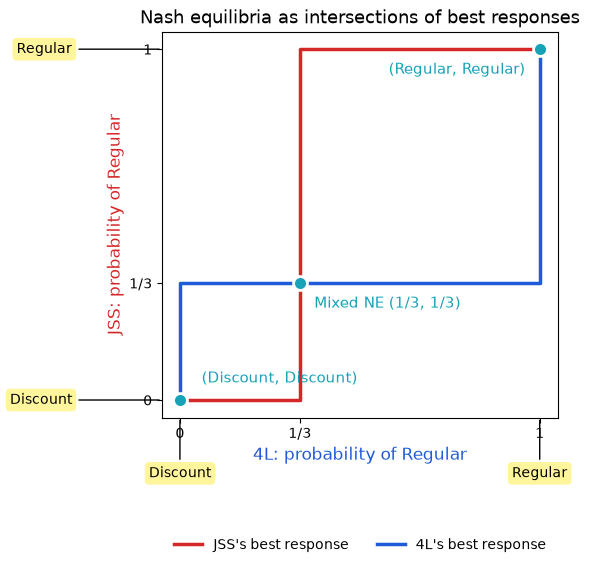

In [5]:
import matplotlib.pyplot as plt

q = float(q_regular)
label_box = dict(boxstyle="round,pad=0.3", facecolor="#fff59d", edgecolor="none")

fig, ax = plt.subplots(figsize=(6, 6))

# JSS's best response (vertical axis) to 4L's P(Regular) on the horizontal axis.
ax.plot([0, q, q, 1], [0, 0, 1, 1], color=P1_COLOR, linewidth=2.5, label=f"{shop_names[0]}'s best response")
# 4L's best response (horizontal axis) to JSS's P(Regular) on the vertical axis.
ax.plot([0, 0, 1, 1], [0, q, q, 1], color=P2_COLOR, linewidth=2.5, label=f"{shop_names[1]}'s best response")

equilibrium_points = [((0, 0), "(Discount, Discount)", (0.06, 0.05)),
                      ((q, q), "Mixed NE (1/3, 1/3)", (0.04, -0.07)),
                      ((1, 1), "(Regular, Regular)", (-0.42, -0.07))]
for (x, y), text, (dx, dy) in equilibrium_points:
    ax.plot(x, y, "o", markersize=10, color="#17a2b8", markeredgecolor="white", markeredgewidth=2, zorder=5)
    ax.annotate(text, (x, y), xytext=(x + dx, y + dy), color="#17a2b8", fontsize=11)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks([0, q, 1], ["0", "1/3", "1"])
ax.set_yticks([0, q, 1], ["0", "1/3", "1"])
ax.set_xlabel(f"{shop_names[1]}: probability of Regular", color=P2_COLOR, fontsize=12)
ax.set_ylabel(f"{shop_names[0]}: probability of Regular", color=P1_COLOR, fontsize=12)
ax.set_title("Nash equilibria as intersections of best responses", fontsize=13)

# Pure-strategy labels on each axis end, like the lecture slides.
for value, text in [(0, "Discount"), (1, "Regular")]:
    ax.annotate(text, xy=(value, -0.05), xytext=(value, -0.22), ha="center", bbox=label_box,
                annotation_clip=False, arrowprops=dict(arrowstyle="-", color="black"))
    ax.annotate(text, xy=(-0.05, value), xytext=(-0.3, value), va="center", ha="right", bbox=label_box,
                annotation_clip=False, arrowprops=dict(arrowstyle="-", color="black"))

ax.legend(loc="upper left", bbox_to_anchor=(0, -0.28), ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## 4. Discussion, limitations, and conclusion

**Answer to the question.** Yes, but through miscoordination rather than a dilemma. Discounting is not always tempting: against a rival charging Regular, a shop earns more by also charging Regular ($1,000 versus $800). But if a shop expects its rival to discount, discounting is its best response, and when both shops hold that expectation they end up at (Discount, Discount), earning $500 each instead of $1,000. The $20 discount and $30 regular prices therefore produce a coordination game. Both (Discount, Discount), with $500 profit per shop, and (Regular, Regular), with $1,000 per shop, are Nash equilibria at the baseline. A mixed equilibrium also exists: each shop chooses Regular with probability $1/3$, for an expected profit of $600. Each shop prefers to match the rival's price, so the one-shot model alone does not determine which equilibrium will occur.

**What the model leaves out.** The numbers are not estimated from observed shops; the purpose is to expose the logic, and other parameter values could change it. Demand is linear over only two prices, customers always buy within this fixed market, and there are no outside options, capacity constraints, product differentiation beyond price, entry, fixed costs, or asymmetric shops. Treating Smiski and Labubu figures as close substitutes is a major simplification: brand loyalty and distinct products could make customers much less willing to switch. The model also abstracts from uncertainty, changing costs, noisy price observation, and finite horizons. Any of these could alter the shops' best responses. Finally, joint shop profit is not a complete welfare measure: lower prices benefit customers in this model, while quality, total demand, and consumer surplus are not modeled.

The main lesson is conditional, not universal: if a shop expects its rival to discount, discounting is privately worthwhile even though mutual discounting lowers both shops' profit relative to (Regular, Regular). Uncertainty about which price the rival will choose, as in the mixed equilibrium, also leaves both shops worse off than if they coordinated on Regular. A more empirical project would estimate customer response and marginal cost from shop price and sales data, then test whether this two-action game remains a useful approximation.

### Reproducibility note

Run the notebook from top to bottom. The code uses Python and pandas; assertions check the baseline demand and equilibria so that key numerical claims are verified rather than only stated.

### AI Note
Claude Code was used in creating this Jupyter notebook through vibe coding and prompting. The information, logic, revisions, and corrections on the work is done by me, as Claude sometimes had information that was a bit off. I tried to base this example off of what we completed in class, but let me know if there are any inaccuracies. Always a work in progress!